# Exploratory Data Analysis of Online Retail Data

## EDA Project

This project performs Exploratory Data Analysis on the Online Retail dataset to identify patterns, trends, relationships, and important factors affecting sales.

### Objectives

- Understand the structure and distribution of the dataset
- Generate statistical summaries
- Analyze sales trends and customer behavior
- Identify relationships between numerical variables
- Identify important influencing factors
- Generate meaningful business insights

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the cleaned dataset from Week 1

file_path = "../output/cleaned_online_retail.csv"

df = pd.read_csv(file_path)

# Convert InvoiceDate back to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

C:\Users\MANISHA\AppData\Local\Temp\ipykernel_8120\40906651.py:5: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Dataset loaded successfully!
Rows: 524845
Columns: 10


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [4]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 524845 entries, 0 to 524844
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524845 non-null  object        
 1   StockCode    524845 non-null  str           
 2   Description  524845 non-null  str           
 3   Quantity     524845 non-null  int64         
 4   InvoiceDate  524845 non-null  datetime64[us]
 5   UnitPrice    524845 non-null  float64       
 6   CustomerID   392662 non-null  float64       
 7   Country      524845 non-null  str           
 8   TotalSales   524845 non-null  float64       
 9   Month        524845 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(1), object(1), str(4)
memory usage: 40.0+ MB


In [5]:
# Statistical summary

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSales
count,524845.000000,524845,524845.000000,392662.000000,524845.000000
mean,6.921605,2011-07-04 15:28:44.317655,2.962248,15287.887445,13.682673
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,8.450000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,16.900000
max,26.000000,2011-12-09 12:50:00,8.450000,18287.000000,219.700000
std,7.565273,NaN,2.397069,1713.498683,17.386649


In [6]:
# Number of unique values

df.nunique()

InvoiceNo      19962
StockCode       3922
Description     4026
Quantity          26
InvoiceDate    18499
UnitPrice        359
CustomerID      4338
Country           38
TotalSales      1824
Month             13
dtype: int64

In [7]:
# Basic numerical statistics

numerical_summary = df[
    ["Quantity", "UnitPrice", "TotalSales"]
].describe()

numerical_summary

,Quantity,UnitPrice,TotalSales
count,524845.000000,524845.000000,524845.000000
mean,6.921605,2.962248,13.682673
std,7.565273,2.397069,17.386649
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,8.450000
75%,11.000000,4.130000,16.900000
max,26.000000,8.450000,219.700000


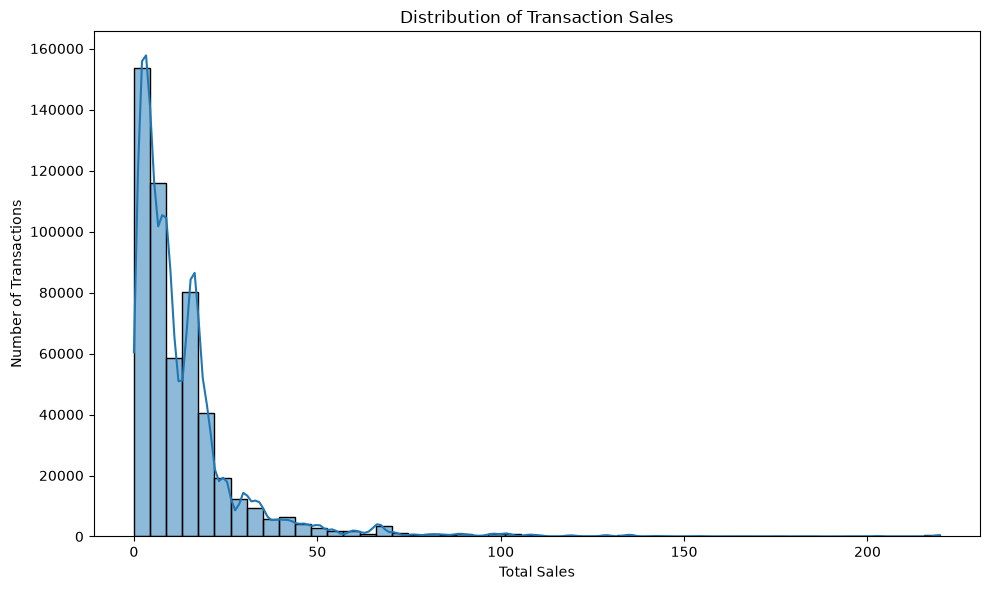

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["TotalSales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Sales")
plt.xlabel("Total Sales")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../visualizations/eda_sales_distribution.png")
plt.show()

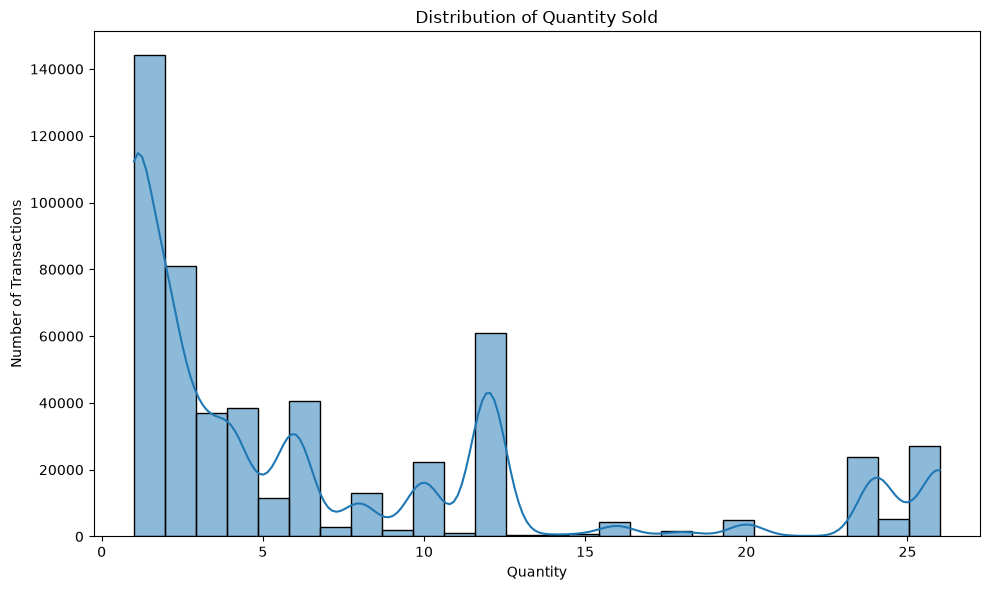

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Quantity"],
    bins=26,
    kde=True
)

plt.title("Distribution of Quantity Sold")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../visualizations/eda_quantity_distribution.png")
plt.show()

In [10]:
# Select numerical variables

numeric_data = df[
    ["Quantity", "UnitPrice", "TotalSales"]
]

correlation_matrix = numeric_data.corr()

correlation_matrix

,Quantity,UnitPrice,TotalSales
Quantity,1.000000,-0.376126,0.523780
UnitPrice,-0.376126,1.000000,0.238714
TotalSales,0.523780,0.238714,1.000000


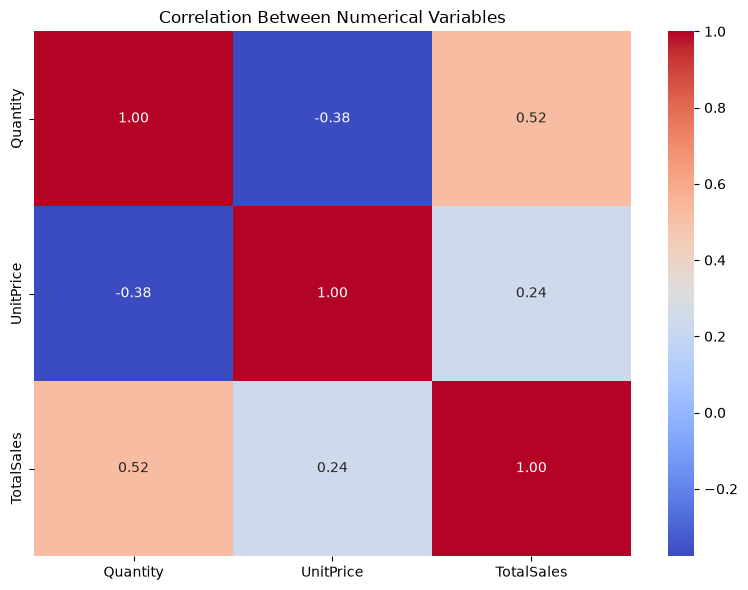

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Variables")

plt.tight_layout()

plt.savefig("../visualizations/eda_correlation_heatmap.png")
plt.show()

In [12]:
# Country-wise sales

country_analysis = (
    df.groupby("Country")
      .agg(
          Total_Revenue=("TotalSales", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Transactions=("InvoiceNo", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

country_analysis.head(10)

,Total_Revenue,Total_Quantity,Transactions
Country,,,
United Kingdom,6173370.454,3101670,18020
Germany,187834.430,101025,458
EIRE,179751.510,89997,288
France,162395.640,91706,392
Netherlands,90528.750,49375,94
Australia,47639.360,21457,57
Switzerland,45047.560,24363,54
Spain,42484.810,22121,90
Belgium,36111.110,20537,98


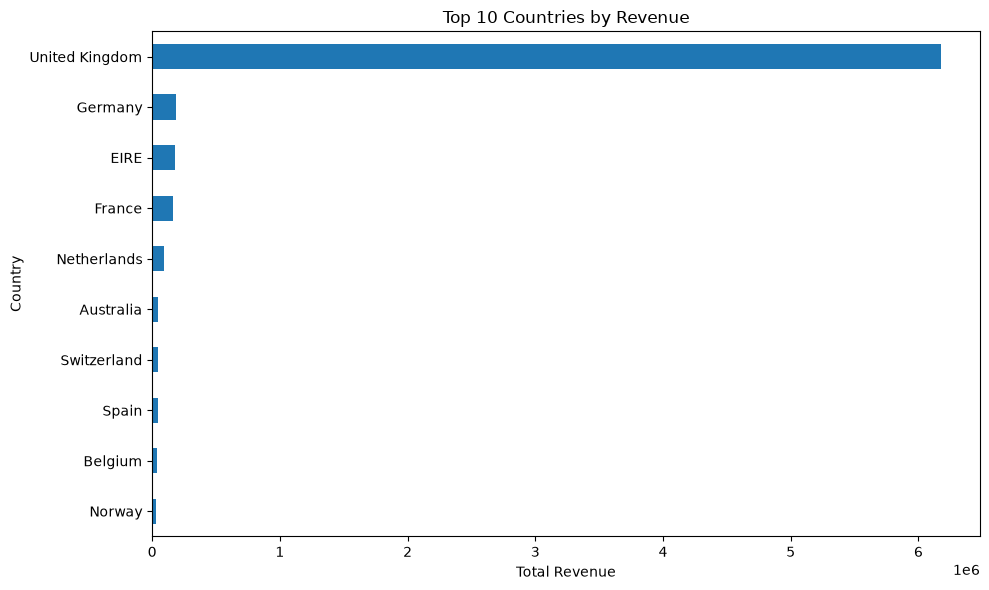

In [13]:
plt.figure(figsize=(10, 6))

country_analysis["Total_Revenue"].head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("../visualizations/eda_country_revenue.png")
plt.show()

In [14]:
# Extract month and calculate monthly revenue

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_analysis = (
    df.groupby("Month")
      .agg(
          Revenue=("TotalSales", "sum"),
          Quantity=("Quantity", "sum"),
          Transactions=("InvoiceNo", "nunique")
      )
)

monthly_analysis

,Revenue,Quantity,Transactions
Month,,,
2010-12,562395.620,242196,1559
2011-01,431308.590,216252,1086
2011-02,373327.690,182131,1100
2011-03,494463.540,245613,1454
2011-04,383757.361,203146,1246
2011-05,540598.020,263057,1681
2011-06,488060.150,251844,1533
2011-07,493249.241,269391,1476
2011-08,503099.260,268419,1361


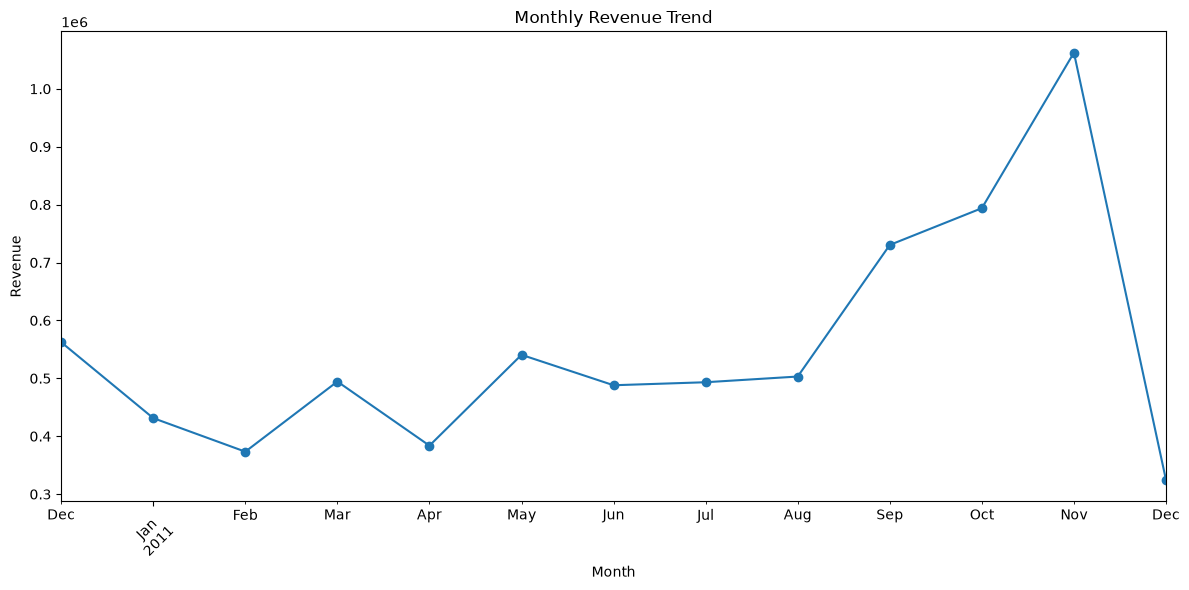

In [15]:
plt.figure(figsize=(12, 6))

monthly_analysis["Revenue"].plot(
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/eda_monthly_revenue.png")
plt.show()

In [16]:
# Country-wise analysis

country_analysis = (
    df.groupby("Country")
      .agg(
          Total_Revenue=("TotalSales", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Transactions=("InvoiceNo", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

country_analysis.head(10)

,Total_Revenue,Total_Quantity,Transactions
Country,,,
United Kingdom,6173370.454,3101670,18020
Germany,187834.430,101025,458
EIRE,179751.510,89997,288
France,162395.640,91706,392
Netherlands,90528.750,49375,94
Australia,47639.360,21457,57
Switzerland,45047.560,24363,54
Spain,42484.810,22121,90
Belgium,36111.110,20537,98


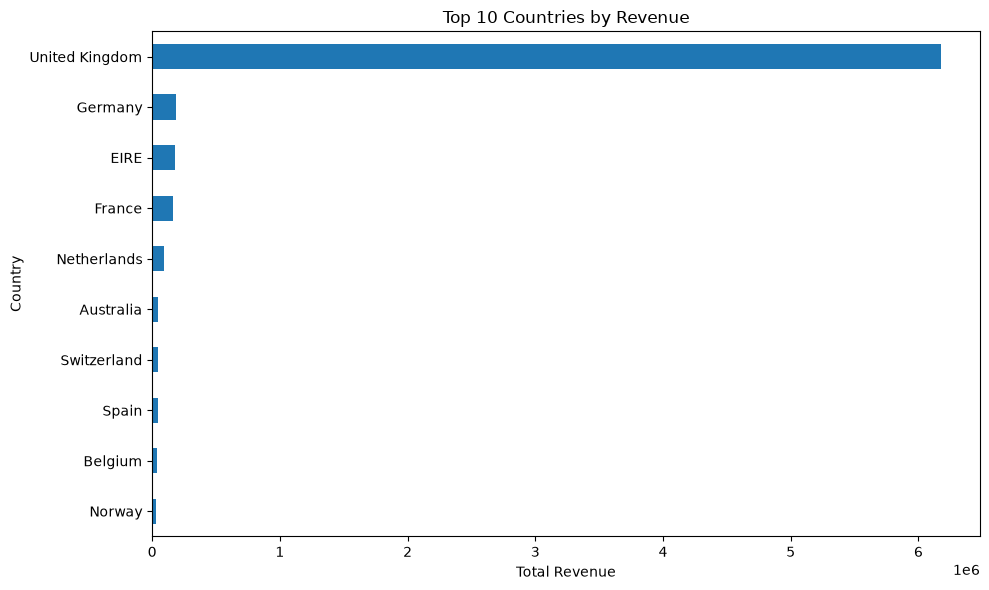

In [17]:
plt.figure(figsize=(10, 6))

country_analysis["Total_Revenue"].head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("../visualizations/eda_country_revenue.png")
plt.show()

In [18]:
# Product-wise revenue analysis

product_analysis = (
    df.groupby("Description")
      .agg(
          Total_Revenue=("TotalSales", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Transactions=("InvoiceNo", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

product_analysis.head(10)

,Total_Revenue,Total_Quantity,Transactions
Description,,,
REGENCY CAKESTAND 3 TIER,93034.80,11034,1988
PARTY BUNTING,64157.76,12239,1685
WHITE HANGING HEART T-LIGHT HOLDER,60604.10,20954,2256
JUMBO BAG RED RETROSPOT,46417.86,21660,2089
PAPER CHAIN KIT 50'S CHRISTMAS,36210.04,11076,1160
ASSORTED COLOUR BIRD ORNAMENT,35690.25,20967,1455
SPOTTY BUNTING,33314.05,6481,1140
CHILLI LIGHTS,32126.28,6068,661
JAM MAKING SET WITH JARS,30359.99,6999,1132


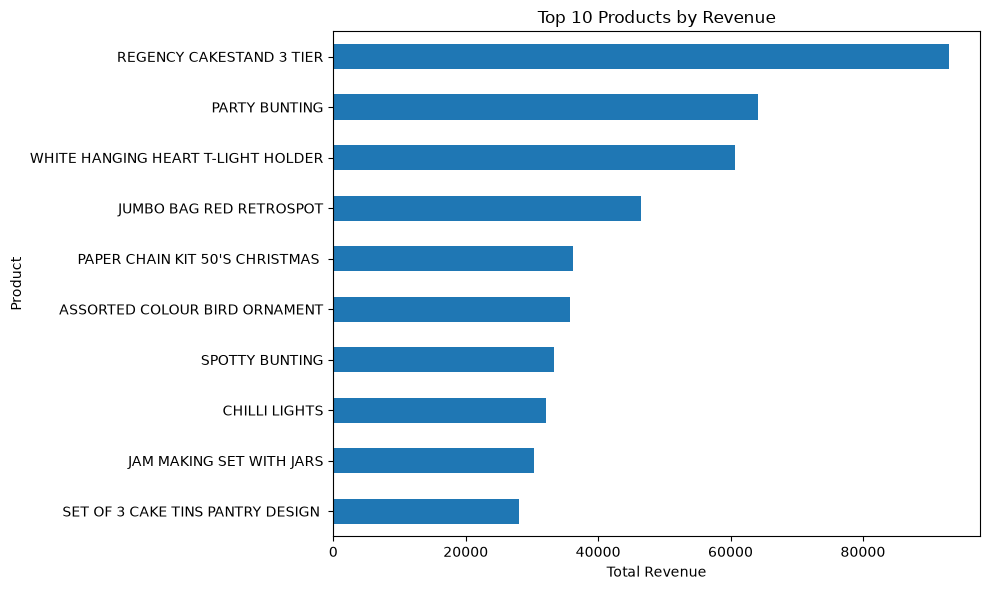

In [19]:
plt.figure(figsize=(10, 6))

product_analysis["Total_Revenue"].head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../visualizations/eda_product_revenue.png")
plt.show()

In [20]:
# Remove customers with missing CustomerID

customer_df = df.dropna(subset=["CustomerID"]).copy()

customer_analysis = (
    customer_df.groupby("CustomerID")
               .agg(
                   Total_Revenue=("TotalSales", "sum"),
                   Total_Quantity=("Quantity", "sum"),
                   Transactions=("InvoiceNo", "nunique")
               )
               .sort_values("Total_Revenue", ascending=False)
)

customer_analysis.head(10)

,Total_Revenue,Total_Quantity,Transactions
CustomerID,,,
14911.0,115011.85,62062,201
14646.0,85888.30,46199,73
13089.0,48777.67,25287,97
14156.0,48300.99,19585,55
14096.0,47494.08,15625,17
18102.0,41866.89,10214,60
17511.0,40291.31,21746,31
14088.0,38934.49,9432,13
14298.0,38181.67,33123,44


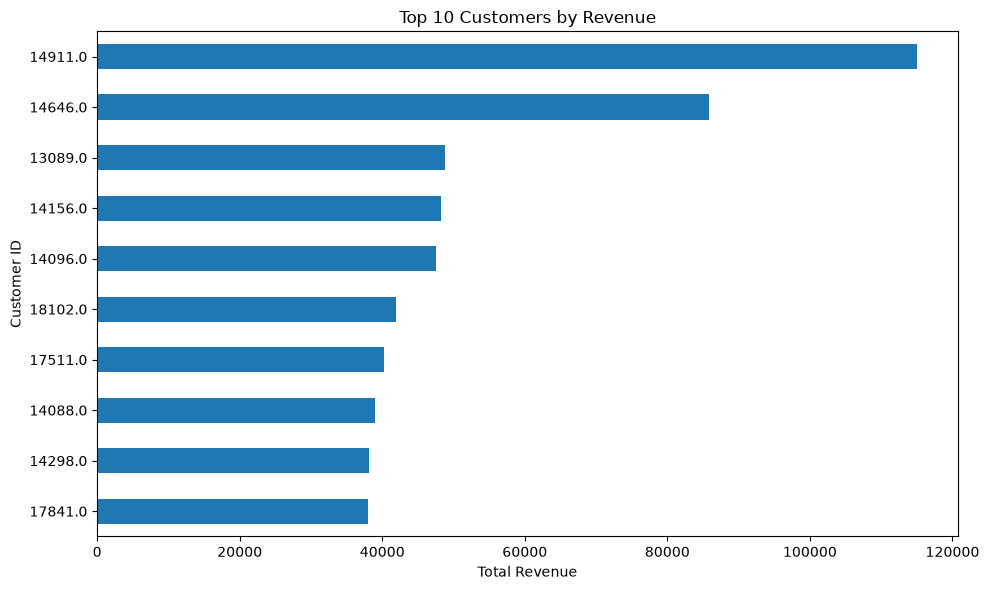

In [21]:
plt.figure(figsize=(10, 6))

customer_analysis["Total_Revenue"].head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig("../visualizations/eda_top_customers.png")
plt.show()

In [22]:
# Monthly transaction volume

monthly_transactions = (
    df.groupby("Month")["InvoiceNo"]
      .nunique()
)

monthly_transactions

Month
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1476
2011-08    1361
2011-09    1838
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: InvoiceNo, dtype: int64

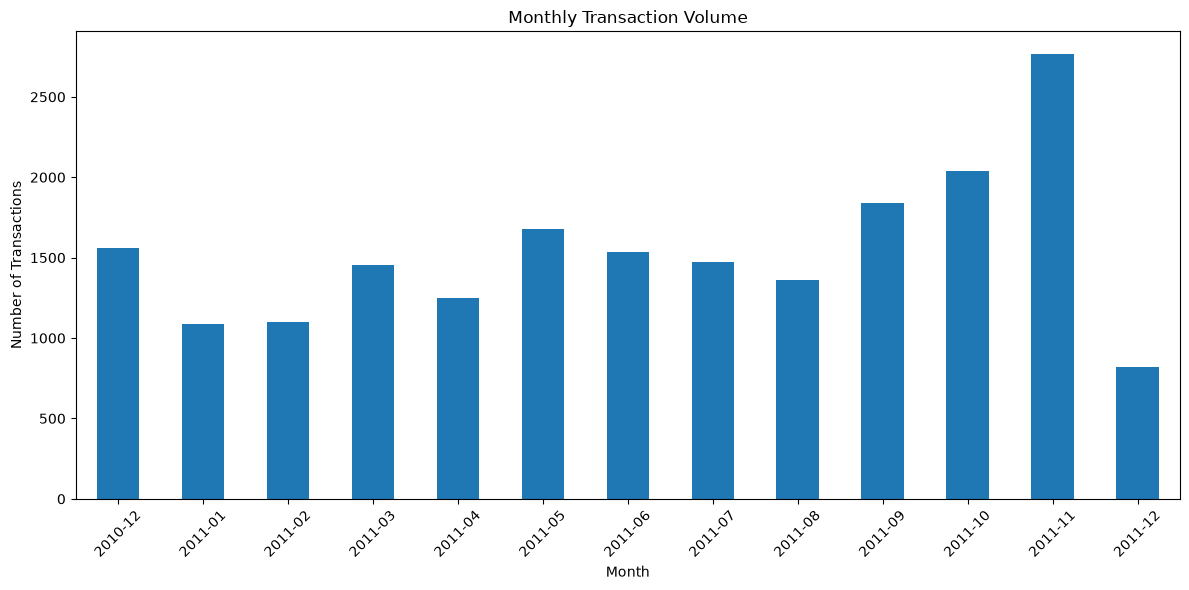

In [23]:
plt.figure(figsize=(12, 6))

monthly_transactions.plot(kind="bar")

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/eda_monthly_transactions.png")
plt.show()

In [24]:
# Statistical summary of important numerical variables

statistical_summary = df[
    ["Quantity", "UnitPrice", "TotalSales"]
].describe().T

statistical_summary

,count,mean,std,min,25%,50%,75%,max
Quantity,524845.0,6.921605,7.565273,1.000,1.00,4.00,11.00,26.00
UnitPrice,524845.0,2.962248,2.397069,0.001,1.25,2.08,4.13,8.45
TotalSales,524845.0,13.682673,17.386649,0.001,3.90,8.45,16.90,219.70


In [25]:
# Median values

median_values = df[
    ["Quantity", "UnitPrice", "TotalSales"]
].median()

print("Median Values:")
print(median_values)

Median Values:
Quantity      4.00
UnitPrice     2.08
TotalSales    8.45
dtype: float64


In [26]:
# Correlation with TotalSales

sales_correlation = (
    df[["Quantity", "UnitPrice", "TotalSales"]]
    .corr()["TotalSales"]
    .sort_values(ascending=False)
)

print("Correlation with TotalSales:")
print(sales_correlation)

Correlation with TotalSales:
TotalSales    1.000000
Quantity      0.523780
UnitPrice     0.238714
Name: TotalSales, dtype: float64


## 11. Key EDA Insights

- Most transactions involve relatively small quantities.
- Transaction sales are right-skewed, with a smaller number of high-value transactions.
- Quantity has a moderate positive correlation with TotalSales.
- UnitPrice has a weaker positive correlation with TotalSales.
- The United Kingdom generates the largest share of revenue.
- REGENCY CAKESTAND 3 TIER is the highest-revenue product in the analysis.
- Customer 14911 has the highest revenue among the top customers shown.
- Transaction activity increases substantially toward November.
- The analysis highlights differences in revenue across countries, products, customers, and months.

# Exploratory Data Analysis – Final Summary

## Project Overview

This project performs Exploratory Data Analysis on an Online Retail dataset to identify important patterns, trends, relationships, and business insights.

## Key Findings

### 1. Sales Distribution
Transaction sales are right-skewed. Most transactions have relatively low sales values, while a smaller number of transactions generate significantly higher sales.

### 2. Quantity Distribution
Most transactions involve relatively small quantities. The distribution also contains transactions with higher quantities.

### 3. Correlation Analysis
- Quantity and TotalSales show a moderate positive correlation of approximately 0.52.
- UnitPrice and TotalSales show a weaker positive correlation of approximately 0.24.
- Quantity and UnitPrice show a moderate negative correlation of approximately -0.38.

### 4. Country Analysis
The United Kingdom contributes the largest share of revenue in the dataset. Other countries contribute considerably smaller amounts compared with the United Kingdom.

### 5. Product Analysis
REGENCY CAKESTAND 3 TIER is the highest-revenue product among the products analyzed.

### 6. Customer Analysis
Customer 14911 has the highest revenue among the top customers identified in the analysis.

### 7. Monthly Transaction Analysis
Transaction activity varies across months, with November showing the highest transaction volume in the analyzed dataset.

## Conclusion

The EDA provides a structured understanding of the Online Retail dataset. The analysis highlights important patterns in sales, quantity, countries, products, customers, and monthly transaction activity. These findings can support further business analysis and predictive modeling.